## 1. Setup

In [4]:
import os
import gc
import json
import time
import random
import warnings
from pathlib import Path
from collections import defaultdict

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import ReduceLROnPlateau

import albumentations as A
from albumentations.pytorch import ToTensorV2

import segmentation_models_pytorch as smp

from sklearn.model_selection import train_test_split

warnings.filterwarnings("ignore")
plt.rcParams["figure.facecolor"] = "white"

print(f"[INFO] PyTorch version : {torch.__version__}")
print(f"[INFO] SMP version     : {smp.__version__}")

[INFO] PyTorch version : 2.10.0+cu128
[INFO] SMP version     : 0.5.0


## 2. Configuration

In [5]:
CONFIG = {
    # --- Dataset sources ---
    "dataset_sources": {
        "PolypDB": "/kaggle/input/datasets/debeshjha1/polypdb/PolypDB/PolypDB/PolypDB_modality_wise",
        "kvasir-SEG": "/kaggle/input/datasets/debeshjha1/kvasirseg/Kvasir-SEG/Kvasir-SEG",
    },
    "output_root": "outputs",

    # --- Data ---
    "image_size": 256,
    "batch_size": 16,
    "num_workers": 4,

    # --- Split ---
    "train_ratio": 0.70,
    "val_ratio": 0.15,
    "test_ratio": 0.15,

    # --- Training ---
    "epochs": 100,                # <- set number of epochs here
    "learning_rate": 1e-4,
    "weight_decay": 1e-5,
    "loss_name": "bce_dice",     # bce | dice | bce_dice
    "early_stopping_patience": 18,

    # --- Model (U-Net only) ---
    "encoder_name": "resnet34",
    "encoder_weights": "imagenet",
    "in_channels": 3,
    "out_channels": 1,

    # --- Metric / threshold ---
    "primary_metric": "dice",
    "binarization_threshold": 0.5,

    # --- Misc ---
    "num_vis_samples": 6,
    "random_seed": 42,
    "device": "cuda" if torch.cuda.is_available() else "cpu",
}

Path(CONFIG["output_root"]).mkdir(parents=True, exist_ok=True)
print(json.dumps(CONFIG, indent=2, default=str))

{
  "dataset_sources": {
    "PolypDB": "/kaggle/input/datasets/debeshjha1/polypdb/PolypDB/PolypDB/PolypDB_modality_wise",
    "kvasir-SEG": "/kaggle/input/datasets/debeshjha1/kvasirseg/Kvasir-SEG/Kvasir-SEG"
  },
  "output_root": "outputs",
  "image_size": 256,
  "batch_size": 16,
  "num_workers": 4,
  "train_ratio": 0.7,
  "val_ratio": 0.15,
  "test_ratio": 0.15,
  "epochs": 100,
  "learning_rate": 0.0001,
  "weight_decay": 1e-05,
  "loss_name": "bce_dice",
  "early_stopping_patience": 18,
  "encoder_name": "resnet34",
  "encoder_weights": "imagenet",
  "in_channels": 3,
  "out_channels": 1,
  "primary_metric": "dice",
  "binarization_threshold": 0.5,
  "num_vis_samples": 6,
  "random_seed": 42,
  "device": "cuda"
}


### 2.1 Reproducibility

In [6]:
def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_seed(CONFIG["random_seed"])
print(f"[INFO] Device: {CONFIG['device'].upper()}")
if torch.cuda.is_available():
    print(f"[INFO] GPU: {torch.cuda.get_device_name(0)}")

[INFO] Device: CUDA
[INFO] GPU: Tesla T4


## 3. Dataset Discovery

In [7]:
IMAGE_EXTS = {".jpg", ".jpeg", ".png"}


def _stem_index(folder: Path) -> dict:
    return {p.stem: p for p in folder.iterdir() if p.is_file() and p.suffix.lower() in IMAGE_EXTS}


def discover_source_dirs(root: str, label: str) -> list:
    '''Return a list of (source_name, images_dir, masks_dir) tuples for one dataset root.'''
    root = Path(root)
    if not root.exists():
        print(f"[WARN] Dataset root not found, skipping: {root}")
        return []

    if (root / "images").is_dir() and (root / "masks").is_dir():
        return [(label, root / "images", root / "masks")]

    found = []
    for child in sorted(root.iterdir()):
        if child.is_dir() and (child / "images").is_dir() and (child / "masks").is_dir():
            found.append((f"{label}_{child.name}", child / "images", child / "masks"))
    return found


def build_manifest(dataset_sources: dict) -> pd.DataFrame:
    rows = []
    for label, root in dataset_sources.items():
        for source_name, img_dir, mask_dir in discover_source_dirs(root, label):
            img_index = _stem_index(img_dir)
            mask_index = _stem_index(mask_dir)
            common = sorted(set(img_index) & set(mask_index))
            for stem in common:
                rows.append({
                    "source": source_name,
                    "sample_id": stem,
                    "image_path": str(img_index[stem]),
                    "mask_path": str(mask_index[stem]),
                })
            missing_masks = set(img_index) - set(mask_index)
            if missing_masks:
                print(f"[WARN] {source_name}: {len(missing_masks)} image(s) with no matching mask")
    return pd.DataFrame(rows)


manifest_df = build_manifest(CONFIG["dataset_sources"])
print("=" * 60)
print("DATASET DISCOVERY SUMMARY")
print("=" * 60)
print(manifest_df.groupby("source").size().rename("valid_pairs").to_string())
print("-" * 60)
print(f"[DATA] Total valid pairs: {len(manifest_df)}")
print("=" * 60)
assert len(manifest_df) > 0, 'No valid image/mask pairs found - check dataset_sources paths.'

DATASET DISCOVERY SUMMARY
source
PolypDB_BLI       70
PolypDB_FICE      70
PolypDB_LCI       60
PolypDB_NBI      146
PolypDB_WLI     3588
kvasir-SEG      1000
------------------------------------------------------------
[DATA] Total valid pairs: 4934


## 4. Validation & Cleaning

In [8]:
def _is_readable(path: str) -> bool:
    try:
        img = cv2.imread(path)
        return img is not None
    except Exception:
        return False


def normalize_mask_array(mask: np.ndarray) -> np.ndarray:
    mask = mask.astype(np.float32)
    if mask.max() > 1.0:
        mask = mask / 255.0
    return (mask > 0.5).astype(np.uint8)


def validate_dataset(df: pd.DataFrame) -> pd.DataFrame:
    records = []
    for row in tqdm(df.itertuples(), total=len(df), desc="[VALIDATION] Checking samples"):
        ok_img = _is_readable(row.image_path)
        ok_mask = _is_readable(row.mask_path)
        rec = dict(row._asdict())
        rec["is_valid"] = ok_img and ok_mask
        if rec["is_valid"]:
            mask_raw = cv2.imread(row.mask_path, cv2.IMREAD_GRAYSCALE)
            mask_norm = normalize_mask_array(mask_raw)
            rec["foreground_ratio"] = float(mask_norm.mean())
            rec["is_empty_mask"] = bool(mask_norm.sum() == 0)
        else:
            rec["foreground_ratio"] = None
            rec["is_empty_mask"] = None
        records.append(rec)
    return pd.DataFrame(records)


validated_df = validate_dataset(manifest_df)
clean_df = validated_df[validated_df["is_valid"]].reset_index(drop=True)

print("=" * 60)
print("VALIDATION SUMMARY")
print("=" * 60)
print(f"Valid samples        : {len(clean_df)} / {len(validated_df)}")
print(f"Empty-mask samples    : {int(clean_df['is_empty_mask'].sum())}")
print(f"Mean foreground ratio : {clean_df['foreground_ratio'].mean():.4f}")
print("=" * 60)

[VALIDATION] Checking samples:   0%|          | 0/4934 [00:00<?, ?it/s]

VALIDATION SUMMARY
Valid samples        : 4934 / 4934
Empty-mask samples    : 0
Mean foreground ratio : 0.0998


## 5. Train / Validation / Test Split

In [9]:
def split_dataset(df: pd.DataFrame, config: dict) -> pd.DataFrame:
    df = df.sample(frac=1.0, random_state=config["random_seed"]).reset_index(drop=True)
    train_df, temp_df = train_test_split(
        df, train_size=config["train_ratio"], random_state=config["random_seed"], shuffle=True
    )
    rel_val = config["val_ratio"] / (config["val_ratio"] + config["test_ratio"])
    val_df, test_df = train_test_split(
        temp_df, train_size=rel_val, random_state=config["random_seed"], shuffle=True
    )
    df.loc[train_df.index, "split"] = "train"
    df.loc[val_df.index, "split"] = "val"
    df.loc[test_df.index, "split"] = "test"
    return df


dataset_df = split_dataset(clean_df, CONFIG)
train_df = dataset_df[dataset_df["split"] == "train"].reset_index(drop=True)
val_df = dataset_df[dataset_df["split"] == "val"].reset_index(drop=True)
test_df = dataset_df[dataset_df["split"] == "test"].reset_index(drop=True)

print("=" * 60)
print("DATASET SUMMARY")
print("=" * 60)
print(f"Total : {len(dataset_df)}")
print(f"Train : {len(train_df)} ({len(train_df) / len(dataset_df):.1%})")
print(f"Val   : {len(val_df)} ({len(val_df) / len(dataset_df):.1%})")
print(f"Test  : {len(test_df)} ({len(test_df) / len(dataset_df):.1%})")
print("=" * 60)
print(dataset_df.groupby(["source", "split"]).size().unstack(fill_value=0).to_string())

DATASET SUMMARY
Total : 4934
Train : 3453 (70.0%)
Val   : 740 (15.0%)
Test  : 741 (15.0%)
split         test  train  val
source                        
PolypDB_BLI     13     47   10
PolypDB_FICE    14     48    8
PolypDB_LCI      6     43   11
PolypDB_NBI     22     99   25
PolypDB_WLI    506   2543  539
kvasir-SEG     180    673  147


## 6. Sample Visualization

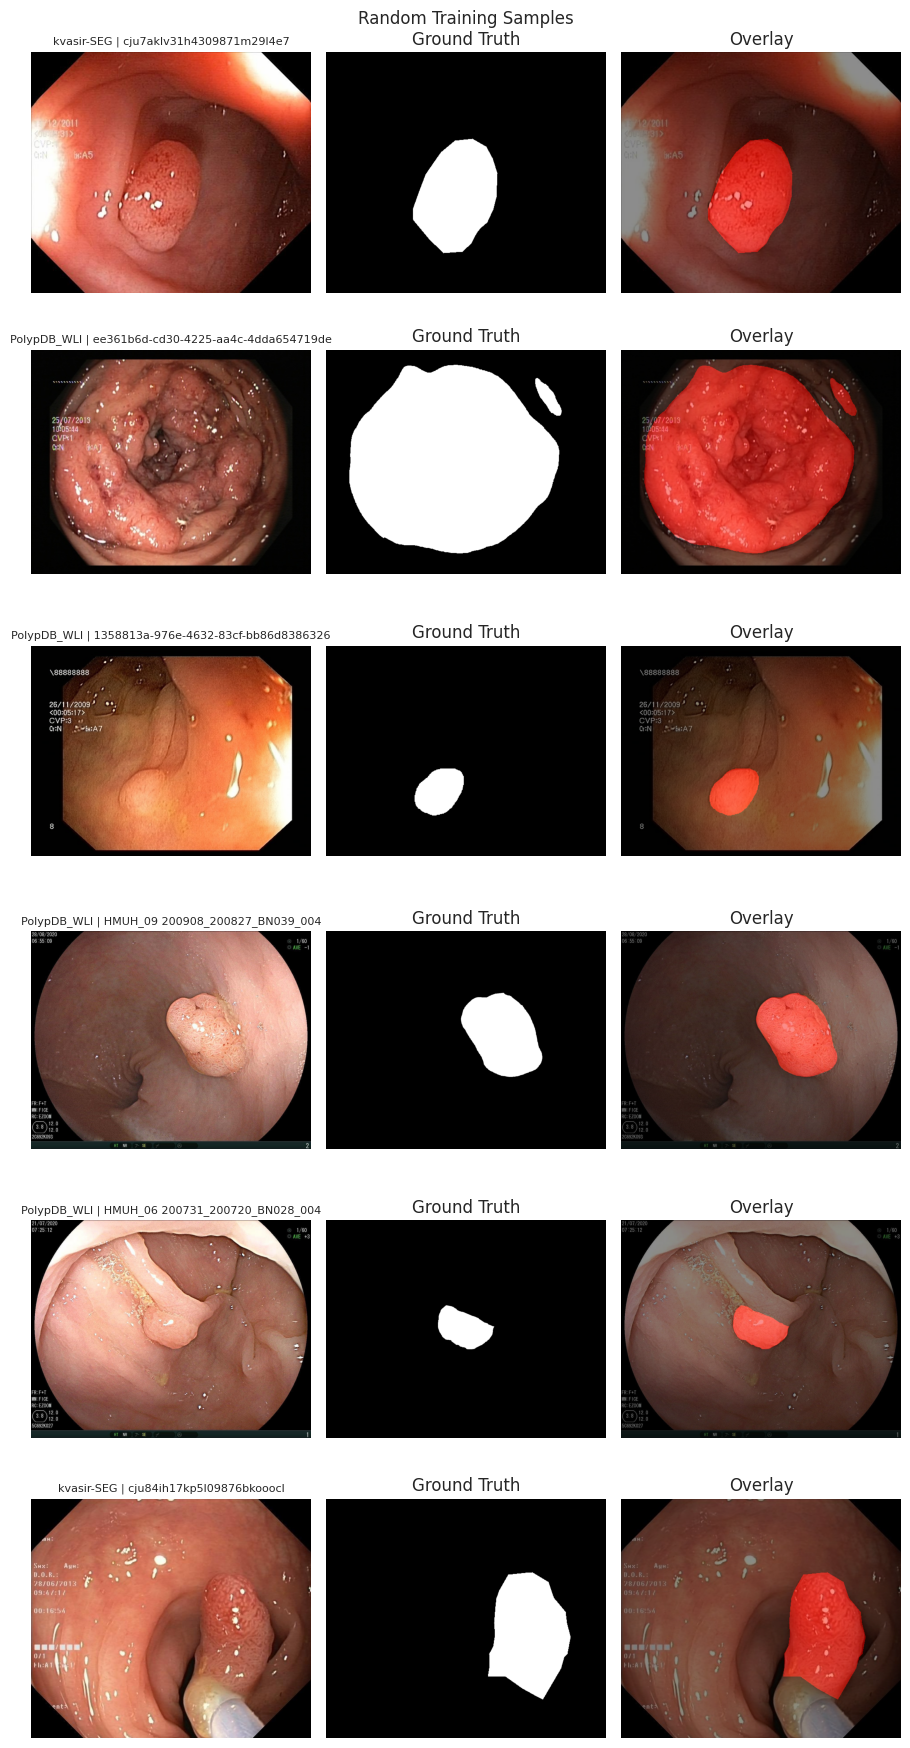

In [10]:
def load_rgb(path: str) -> np.ndarray:
    img = cv2.imread(path)
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)


def load_mask(path: str) -> np.ndarray:
    return normalize_mask_array(cv2.imread(path, cv2.IMREAD_GRAYSCALE))


def overlay_mask(image: np.ndarray, mask: np.ndarray, color=(255, 0, 0), alpha=0.45) -> np.ndarray:
    colored = np.zeros_like(image)
    colored[mask > 0] = color
    return cv2.addWeighted(colored, alpha, image, 1 - alpha, 0)


def visualize_samples(df: pd.DataFrame, n: int = 6, seed: int = 42, title: str = "Samples"):
    sample = df.sample(n=min(n, len(df)), random_state=seed)
    fig, axes = plt.subplots(len(sample), 3, figsize=(9, 3 * len(sample)))
    if len(sample) == 1:
        axes = axes[None, :]
    for i, row in enumerate(sample.itertuples()):
        img = load_rgb(row.image_path)
        mask = load_mask(row.mask_path)
        ov = overlay_mask(img, mask)
        axes[i, 0].imshow(img); axes[i, 0].set_title(f"{row.source} | {row.sample_id}", fontsize=8)
        axes[i, 1].imshow(mask, cmap="gray"); axes[i, 1].set_title("Ground Truth")
        axes[i, 2].imshow(ov); axes[i, 2].set_title("Overlay")
        for ax in axes[i]:
            ax.axis("off")
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


visualize_samples(train_df, n=CONFIG["num_vis_samples"], title="Random Training Samples")

## 7. Transforms, Dataset & DataLoaders

In [11]:
IMG_SIZE = CONFIG["image_size"]

TRAIN_TRANSFORMS = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE, interpolation=cv2.INTER_LINEAR, mask_interpolation=cv2.INTER_NEAREST),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.RandomBrightnessContrast(p=0.3),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

VAL_TRANSFORMS = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE, interpolation=cv2.INTER_LINEAR, mask_interpolation=cv2.INTER_NEAREST),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

TEST_TRANSFORMS = VAL_TRANSFORMS


class PolypSegmentationDataset(Dataset):
    def __init__(self, df: pd.DataFrame, transforms: A.Compose):
        self.df = df.reset_index(drop=True)
        self.transforms = transforms

    def __len__(self) -> int:
        return len(self.df)

    def __getitem__(self, idx: int) -> dict:
        row = self.df.iloc[idx]
        image = load_rgb(row["image_path"])
        mask = load_mask(row["mask_path"])
        aug = self.transforms(image=image, mask=mask)
        return {
            "image": aug["image"].float(),
            "mask": aug["mask"].float().unsqueeze(0),
            "id": row["sample_id"],
            "source": row["source"],
        }


train_dataset = PolypSegmentationDataset(train_df, TRAIN_TRANSFORMS)
val_dataset = PolypSegmentationDataset(val_df, VAL_TRANSFORMS)
test_dataset = PolypSegmentationDataset(test_df, TEST_TRANSFORMS)

loader_kwargs = dict(num_workers=CONFIG["num_workers"], pin_memory=True)
train_loader = DataLoader(train_dataset, batch_size=CONFIG["batch_size"], shuffle=True, drop_last=True, **loader_kwargs)
val_loader = DataLoader(val_dataset, batch_size=CONFIG["batch_size"], shuffle=False, **loader_kwargs)
test_loader = DataLoader(test_dataset, batch_size=CONFIG["batch_size"], shuffle=False, **loader_kwargs)

print(f"[DATA] Train batches: {len(train_loader)} | Val batches: {len(val_loader)} | Test batches: {len(test_loader)}")

[DATA] Train batches: 215 | Val batches: 47 | Test batches: 47


## 8. U-Net Model

In [12]:
def build_unet(config: dict) -> nn.Module:
    return smp.Unet(
        encoder_name=config["encoder_name"],
        encoder_weights=config["encoder_weights"],
        in_channels=config["in_channels"],
        classes=config["out_channels"],
        activation=None, 
    )


model = build_unet(CONFIG).to(CONFIG["device"])

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("[MODEL] U-Net")
print(f"Encoder            : {CONFIG['encoder_name']} ({CONFIG['encoder_weights']})")
print(f"Total parameters    : {total_params / 1e6:.2f}M")
print(f"Trainable parameters: {trainable_params / 1e6:.2f}M")

config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

[MODEL] U-Net
Encoder            : resnet34 (imagenet)
Total parameters    : 24.44M
Trainable parameters: 24.44M


## 9. Loss & Metrics

In [13]:
class DiceLoss(nn.Module):
    def __init__(self, eps: float = 1e-7):
        super().__init__()
        self.eps = eps

    def forward(self, logits, targets):
        probs = torch.sigmoid(logits).flatten(1)
        targets = targets.flatten(1)
        intersection = (probs * targets).sum(dim=1)
        union = probs.sum(dim=1) + targets.sum(dim=1)
        dice = (2 * intersection + self.eps) / (union + self.eps)
        return 1.0 - dice.mean()


class BCEDiceLoss(nn.Module):
    def __init__(self, bce_weight: float = 0.5):
        super().__init__()
        self.bce = nn.BCEWithLogitsLoss()
        self.dice = DiceLoss()
        self.bce_weight = bce_weight

    def forward(self, logits, targets):
        return self.bce_weight * self.bce(logits, targets) + (1 - self.bce_weight) * self.dice(logits, targets)


def get_loss(name: str) -> nn.Module:
    return {"bce": nn.BCEWithLogitsLoss(), "dice": DiceLoss(), "bce_dice": BCEDiceLoss()}[name]


def compute_confusion(preds, targets):
    preds = preds.flatten(1)
    targets = targets.flatten(1)
    tp = (preds * targets).sum(dim=1)
    fp = (preds * (1 - targets)).sum(dim=1)
    fn = ((1 - preds) * targets).sum(dim=1)
    tn = ((1 - preds) * (1 - targets)).sum(dim=1)
    return tp, fp, fn, tn


def segmentation_metrics(logits, targets, threshold: float = 0.5, eps: float = 1e-7) -> dict:
    probs = torch.sigmoid(logits)
    preds = (probs > threshold).float()
    tp, fp, fn, tn = compute_confusion(preds, targets)
    dice = (2 * tp + eps) / (2 * tp + fp + fn + eps)
    iou = (tp + eps) / (tp + fp + fn + eps)
    precision = (tp + eps) / (tp + fp + eps)
    recall = (tp + eps) / (tp + fn + eps)
    return {
        "dice": dice.mean().item(), "iou": iou.mean().item(),
        "precision": precision.mean().item(), "recall": recall.mean().item(),
    }

## 10. Training Loop

In [14]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    running = defaultdict(float)
    for batch in loader:
        images = batch["image"].to(device)
        masks = batch["mask"].to(device)
        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, masks)
        loss.backward()
        optimizer.step()
        with torch.no_grad():
            metrics = segmentation_metrics(logits, masks, CONFIG["binarization_threshold"])
        running["loss"] += loss.item()
        for k, v in metrics.items():
            running[k] += v
    return {k: v / len(loader) for k, v in running.items()}


@torch.no_grad()
def validate_one_epoch(model, loader, criterion, device):
    model.eval()
    running = defaultdict(float)
    for batch in loader:
        images = batch["image"].to(device)
        masks = batch["mask"].to(device)
        logits = model(images)
        loss = criterion(logits, masks)
        metrics = segmentation_metrics(logits, masks, CONFIG["binarization_threshold"])
        running["loss"] += loss.item()
        for k, v in metrics.items():
            running[k] += v
    return {k: v / len(loader) for k, v in running.items()}

In [ ]:
EXPERIMENT_DIR = Path(CONFIG["output_root"]) / "unet"
CHECKPOINT_DIR = EXPERIMENT_DIR / "checkpoints"
for sub_dir in [CHECKPOINT_DIR, EXPERIMENT_DIR / "plots", EXPERIMENT_DIR / "metrics", EXPERIMENT_DIR / "predictions"]:
    sub_dir.mkdir(parents=True, exist_ok=True)

criterion = get_loss(CONFIG["loss_name"])
optimizer = torch.optim.AdamW(model.parameters(), lr=CONFIG["learning_rate"], weight_decay=CONFIG["weight_decay"])
scheduler = ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=5)

history = []
best_epoch, best_val_metric = 0, -float("inf")
patience_counter = 0
training_start = time.time()

for epoch in range(1, CONFIG["epochs"] + 1):
    epoch_start = time.time()

    train_metrics = train_one_epoch(model, train_loader, optimizer, criterion, CONFIG["device"])
    val_metrics = validate_one_epoch(model, val_loader, criterion, CONFIG["device"])
    scheduler.step(val_metrics[CONFIG["primary_metric"]])

    epoch_time = time.time() - epoch_start
    row = {"epoch": epoch, "epoch_time_sec": epoch_time, "learning_rate": optimizer.param_groups[0]["lr"]}
    row.update({f"train_{k}": v for k, v in train_metrics.items()})
    row.update({f"val_{k}": v for k, v in val_metrics.items()})
    history.append(row)

    monitored = val_metrics[CONFIG["primary_metric"]]
    is_best = monitored > best_val_metric
    state = {"epoch": epoch, "model_state_dict": model.state_dict(), "best_metric": monitored, "config": CONFIG}
    torch.save(state, CHECKPOINT_DIR / "last_model.pth")
    if is_best:
        best_val_metric = monitored
        best_epoch = epoch
        patience_counter = 0
        torch.save(state, CHECKPOINT_DIR / "best_model.pth")
    else:
        patience_counter += 1

    print(f"[Epoch {epoch:03d}/{CONFIG['epochs']}] "
          f"train_loss={train_metrics['loss']:.4f} val_loss={val_metrics['loss']:.4f} | "
          f"train_dice={train_metrics['dice']:.4f} val_dice={val_metrics['dice']:.4f} | "
          f"val_iou={val_metrics['iou']:.4f} | {epoch_time:.1f}s"
          + ("  <- best" if is_best else ""))

    if patience_counter >= CONFIG["early_stopping_patience"]:
        print(f"[INFO] Early stopping triggered at epoch {epoch} (no improvement for {patience_counter} epochs).")
        break

total_time_sec = time.time() - training_start
history_df = pd.DataFrame(history)
history_df.to_csv(EXPERIMENT_DIR / "metrics" / "training_history.csv", index=False)

print("=" * 60)
print(f"[DONE] Training finished in {total_time_sec / 60:.1f} min")
print(f"[DONE] Best epoch: {best_epoch} | Best val {CONFIG['primary_metric']}: {best_val_metric:.4f}")
print("=" * 60)

[Epoch 001/100] train_loss=0.5408 val_loss=0.4225 | train_dice=0.5918 val_dice=0.7442 | val_iou=0.6494 | 51.2s  <- best
[Epoch 002/100] train_loss=0.3496 val_loss=0.3008 | train_dice=0.7826 val_dice=0.7873 | val_iou=0.6958 | 51.1s  <- best
[Epoch 003/100] train_loss=0.2418 val_loss=0.2033 | train_dice=0.8301 val_dice=0.8483 | val_iou=0.7722 | 52.2s  <- best
[Epoch 004/100] train_loss=0.1782 val_loss=0.1578 | train_dice=0.8529 val_dice=0.8459 | val_iou=0.7695 | 52.6s
[Epoch 005/100] train_loss=0.1471 val_loss=0.1397 | train_dice=0.8569 val_dice=0.8508 | val_iou=0.7759 | 53.7s  <- best
[Epoch 006/100] train_loss=0.1298 val_loss=0.1326 | train_dice=0.8655 val_dice=0.8564 | val_iou=0.7828 | 54.0s  <- best
[Epoch 007/100] train_loss=0.1140 val_loss=0.1155 | train_dice=0.8770 val_dice=0.8701 | val_iou=0.8045 | 54.1s  <- best
[Epoch 008/100] train_loss=0.1088 val_loss=0.1302 | train_dice=0.8779 val_dice=0.8471 | val_iou=0.7780 | 54.6s
[Epoch 009/100] train_loss=0.1009 val_loss=0.1145 | train_

## 11. Training Curves

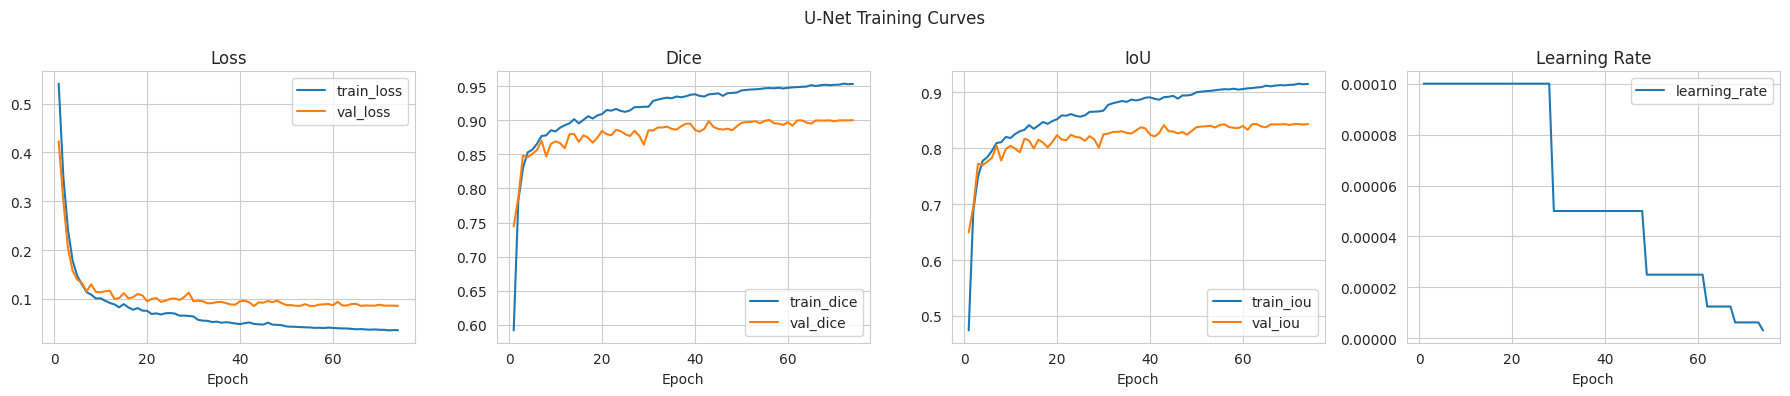

In [16]:
def plot_training_history(history_df: pd.DataFrame, save_dir: Path):
    save_dir.mkdir(parents=True, exist_ok=True)
    panels = [
        ("loss", ["train_loss", "val_loss"], "Loss"),
        ("dice", ["train_dice", "val_dice"], "Dice"),
        ("iou", ["train_iou", "val_iou"], "IoU"),
        ("lr", ["learning_rate"], "Learning Rate"),
    ]
    fig, axes = plt.subplots(1, len(panels), figsize=(18, 4))
    for ax, (fname, cols, title) in zip(axes, panels):
        for col in cols:
            ax.plot(history_df["epoch"], history_df[col], label=col)
        ax.set_title(title); ax.set_xlabel("Epoch"); ax.legend()
    fig.suptitle("U-Net Training Curves")
    plt.tight_layout()
    plt.savefig(save_dir / "training_curves.png", dpi=150)
    plt.show()


plot_training_history(history_df, EXPERIMENT_DIR / "plots")

## 12. Test Evaluation

In [17]:
def load_best_model(config: dict) -> nn.Module:
    m = build_unet(config).to(config["device"])
    ckpt = torch.load(CHECKPOINT_DIR / "best_model.pth", map_location=config["device"])
    m.load_state_dict(ckpt["model_state_dict"])
    m.eval()
    print(f"[TEST] Loaded best checkpoint (epoch {ckpt['epoch']}, "
          f"{config['primary_metric']}={ckpt['best_metric']:.4f})")
    return m


@torch.no_grad()
def evaluate_model(model: nn.Module, loader: DataLoader, config: dict) -> pd.DataFrame:
    device = config["device"]
    rows = []
    for batch in tqdm(loader, desc="[TEST] Evaluating"):
        images = batch["image"].to(device)
        masks = batch["mask"].to(device)
        logits = model(images)
        for i in range(images.shape[0]):
            m = segmentation_metrics(logits[i:i + 1], masks[i:i + 1], config["binarization_threshold"])
            rows.append({"sample_id": batch["id"][i], "source": batch["source"][i], **m})
    return pd.DataFrame(rows)


best_model = load_best_model(CONFIG)
per_sample_test_df = evaluate_model(best_model, test_loader, CONFIG)
per_sample_test_df.to_csv(EXPERIMENT_DIR / "metrics" / "per_sample_test_metrics.csv", index=False)

print("=" * 60)
print("FINAL TEST RESULTS — U-Net")
print("=" * 60)
print(f"Dice      : {per_sample_test_df['dice'].mean():.4f}")
print(f"IoU       : {per_sample_test_df['iou'].mean():.4f}")
print(f"Precision : {per_sample_test_df['precision'].mean():.4f}")
print(f"Recall    : {per_sample_test_df['recall'].mean():.4f}")
print("=" * 60)

print("\nPER-SOURCE TEST METRICS")
print(per_sample_test_df.groupby("source")[["dice", "iou", "precision", "recall"]].mean().to_string())

[TEST] Loaded best checkpoint (epoch 56, dice=0.9006)


[TEST] Evaluating:   0%|          | 0/47 [00:00<?, ?it/s]

FINAL TEST RESULTS — U-Net
Dice      : 0.9014
IoU       : 0.8466
Precision : 0.9201
Recall    : 0.9046

PER-SOURCE TEST METRICS
                  dice       iou  precision    recall
source                                               
PolypDB_BLI   0.777563  0.700289   0.799447  0.799646
PolypDB_FICE  0.798120  0.723983   0.844042  0.790494
PolypDB_LCI   0.834770  0.764886   0.904093  0.858913
PolypDB_NBI   0.877941  0.805275   0.910566  0.877376
PolypDB_WLI   0.904183  0.850520   0.919094  0.907319
kvasir-SEG    0.915584  0.863437   0.939442  0.918262


## 13. Prediction Visualization

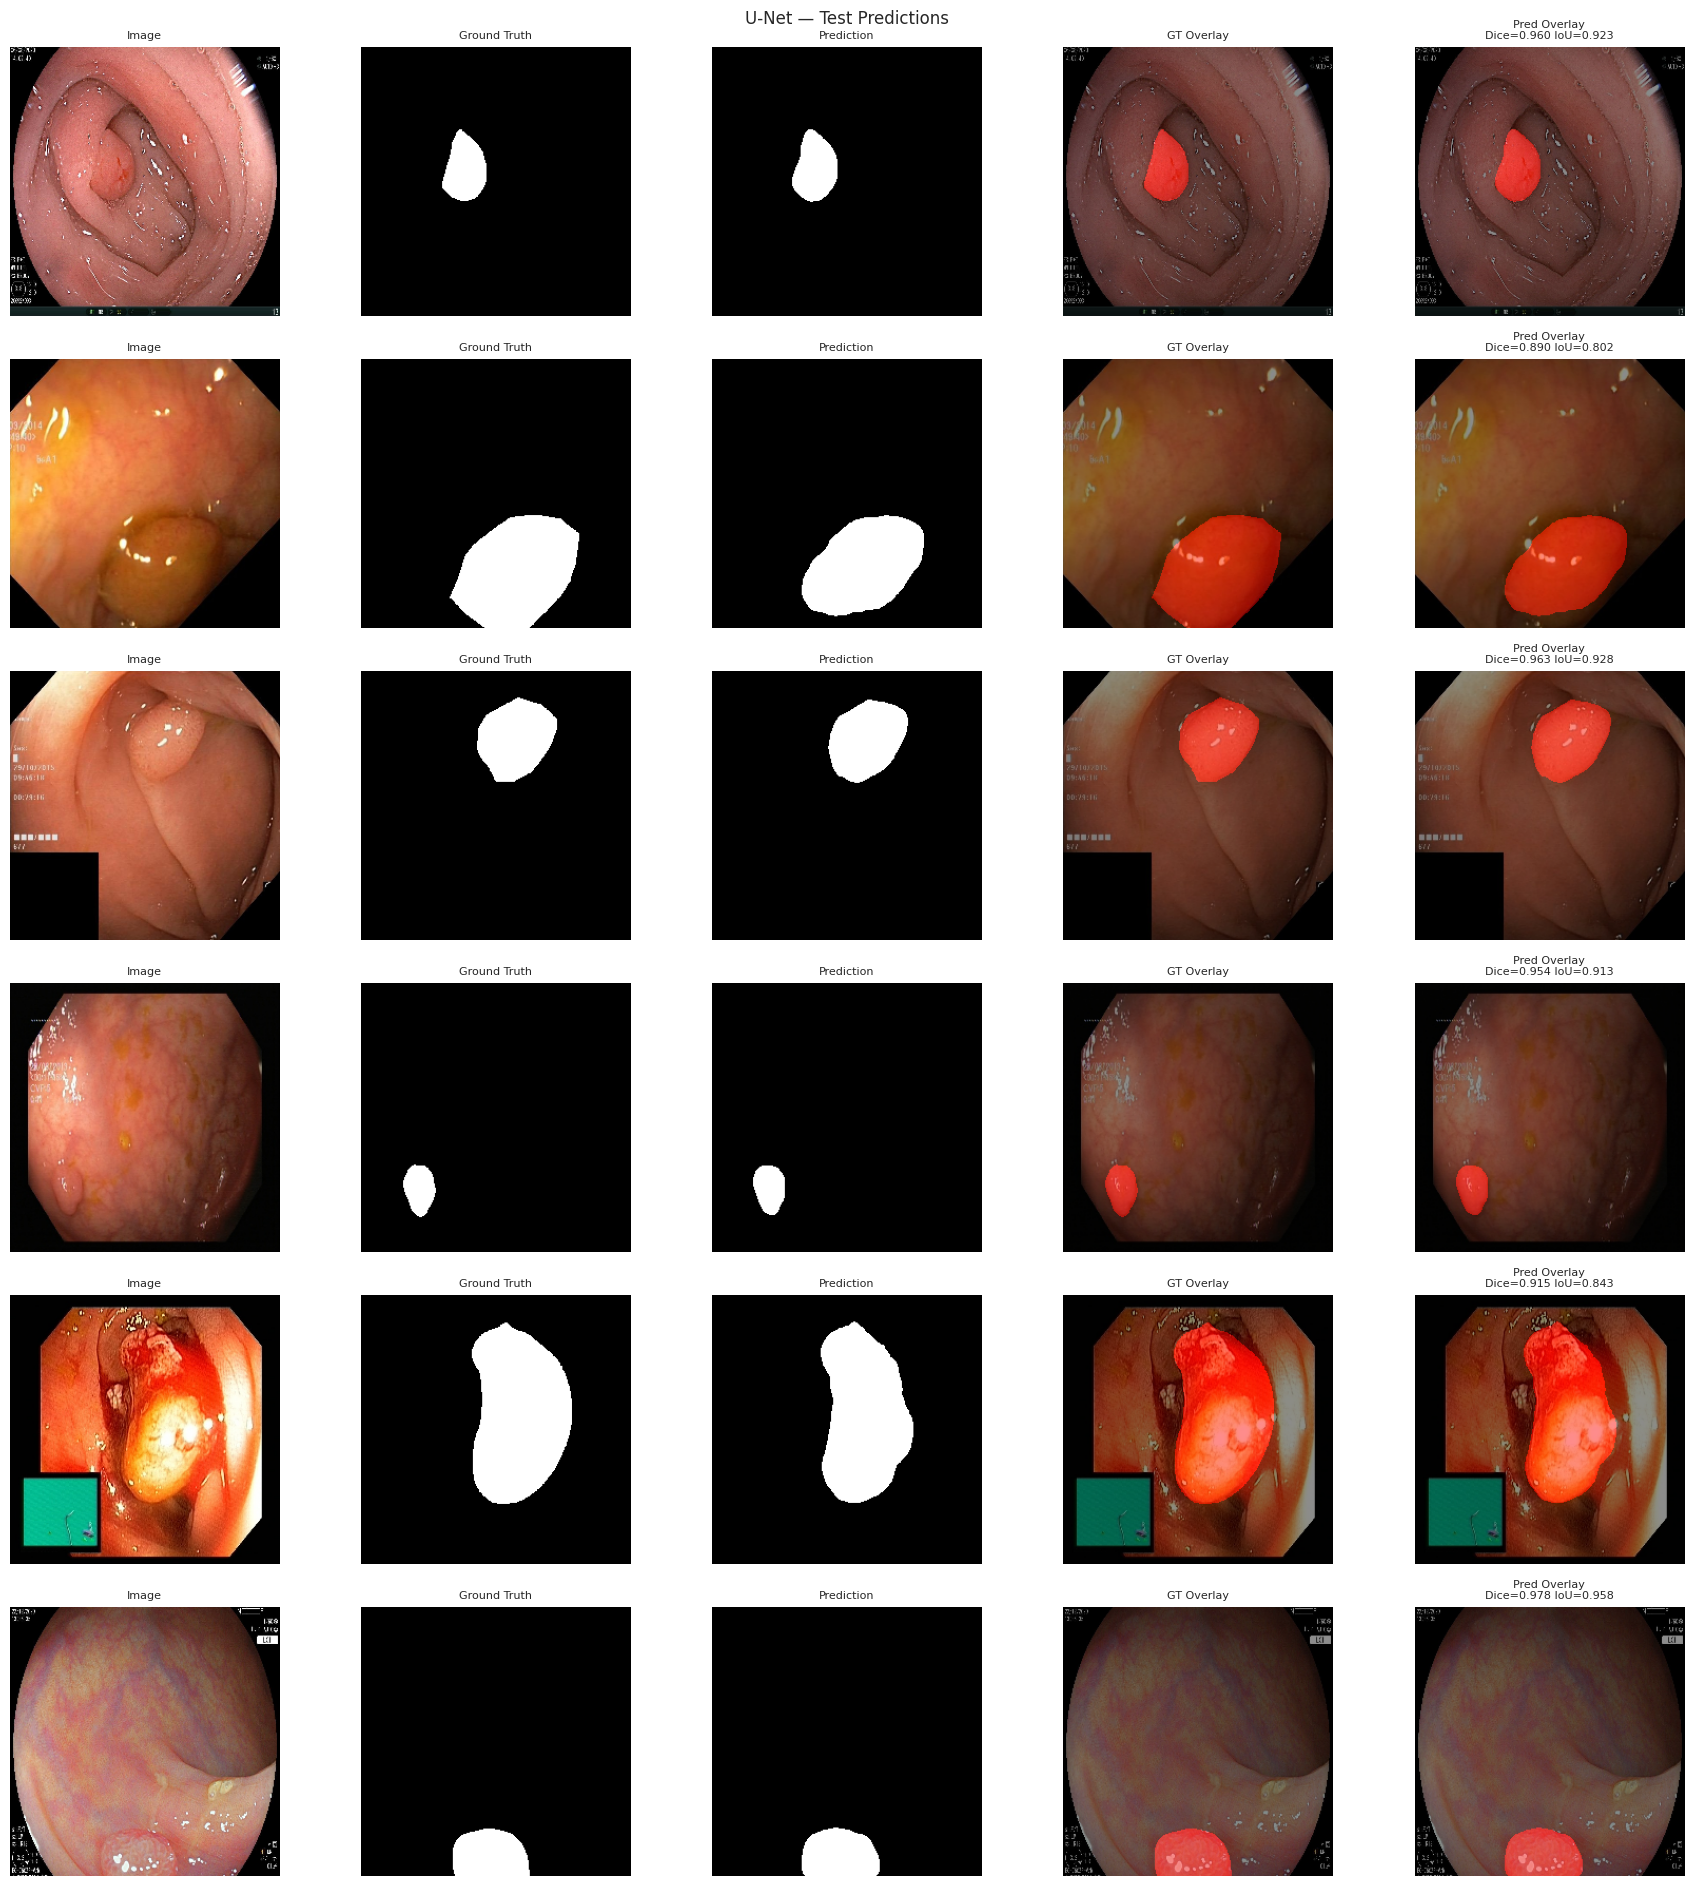

In [18]:
@torch.no_grad()
def visualize_predictions(model: nn.Module, test_df: pd.DataFrame, config: dict, n: int = 6, seed: int = 7):
    sample_df = test_df.sample(n=min(n, len(test_df)), random_state=seed)
    fig, axes = plt.subplots(len(sample_df), 5, figsize=(18, 3.2 * len(sample_df)))
    for i, row in enumerate(sample_df.itertuples()):
        img = load_rgb(row.image_path)
        gt = load_mask(row.mask_path)
        aug = TEST_TRANSFORMS(image=img, mask=gt)
        inp = aug["image"].unsqueeze(0).to(config["device"])
        logits = model(inp)
        prob = torch.sigmoid(logits)[0, 0].cpu().numpy()
        pred = (prob > config["binarization_threshold"]).astype(np.uint8)

        img_r = cv2.resize(img, (config["image_size"], config["image_size"]))
        gt_r = cv2.resize(gt, (config["image_size"], config["image_size"]), interpolation=cv2.INTER_NEAREST)

        m = segmentation_metrics(logits, aug["mask"].unsqueeze(0).unsqueeze(0).to(config["device"]), config["binarization_threshold"])

        panels = [img_r, gt_r, pred, overlay_mask(img_r, gt_r), overlay_mask(img_r, pred)]
        titles = ["Image", "Ground Truth", "Prediction", "GT Overlay", f"Pred Overlay\nDice={m['dice']:.3f} IoU={m['iou']:.3f}"]
        for j, (panel, title) in enumerate(zip(panels, titles)):
            cmap = "gray" if panel.ndim == 2 else None
            axes[i, j].imshow(panel, cmap=cmap); axes[i, j].set_title(title, fontsize=8); axes[i, j].axis("off")

    fig.suptitle("U-Net — Test Predictions")
    plt.tight_layout()
    plt.savefig(EXPERIMENT_DIR / "predictions" / "sample_predictions.png", dpi=150)
    plt.show()


visualize_predictions(best_model, test_df, CONFIG, n=CONFIG["num_vis_samples"])

## 14. Save Final Results

In [19]:
final_report = {
    "config": {k: v for k, v in CONFIG.items()},
    "best_epoch": best_epoch,
    "best_val_metric": best_val_metric,
    "total_training_time_min": total_time_sec / 60,
    "test_metrics": {
        "dice": float(per_sample_test_df["dice"].mean()),
        "iou": float(per_sample_test_df["iou"].mean()),
        "precision": float(per_sample_test_df["precision"].mean()),
        "recall": float(per_sample_test_df["recall"].mean()),
    },
    "test_metrics_per_source": (
        per_sample_test_df.groupby("source")[["dice", "iou", "precision", "recall"]]
        .mean().reset_index().to_dict(orient="records")
    ),
    "best_checkpoint": str(CHECKPOINT_DIR / "best_model.pth"),
}

with open(EXPERIMENT_DIR / "final_report.json", "w") as f:
    json.dump(final_report, f, indent=2, default=str)

print("[SAVE] training_history.csv written.")
print("[SAVE] per_sample_test_metrics.csv written.")
print("[SAVE] training_curves.png / sample_predictions.png written.")
print("[SAVE] best_model.pth / last_model.pth written.")
print(f"[SAVE] final_report.json written to {EXPERIMENT_DIR / 'final_report.json'}")

[SAVE] training_history.csv written.
[SAVE] per_sample_test_metrics.csv written.
[SAVE] training_curves.png / sample_predictions.png written.
[SAVE] best_model.pth / last_model.pth written.
[SAVE] final_report.json written to outputs/unet/final_report.json
